In [1]:
import os
import pandas as pd
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt

# Change root directory to the repo root (Jupyter: __file__ is not defined)
def find_repo_root(start=Path.cwd()):
	for p in [start] + list(start.parents):
		if (p / 'Code').exists() or (p / '.git').exists() or (p / 'local_repo').exists():
			return p
	return start

repo_root = find_repo_root()
data_root = repo_root.parent.parent / 'Data' / 'CBOS ready'
geo_root = repo_root.parent.parent / 'Data' / 'Geospatial'

In [2]:
# API key: c2ccd182-be71-41ee-6a99-08de61444905
# Another: 1de25faa-0796-4036-6a9c-08de61444905
# Another: 80b20037-8e82-42ec-6a9f-08de61444905
# Another: a2dbb3a9-026c-4aa5-6aa0-08de61444905
# Another: ed928d84-8050-4861-6aa1-08de61444905

import requests
from pandas import json_normalize
import time

API_KEYS = ['1de25faa-0796-4036-6a9c-08de61444905', '80b20037-8e82-42ec-6a9f-08de61444905', 'a2dbb3a9-026c-4aa5-6aa0-08de61444905', 'ed928d84-8050-4861-6aa1-08de61444905', 'c2ccd182-be71-41ee-6a99-08de61444905']

API_BASE = "https://bdl.stat.gov.pl/api/v1"
API_KEY = API_KEYS[0]
# os.getenv("BDL_API_KEY")  # optional: export BDL_API_KEY to raise rate limits

HEADERS = {"User-Agent": "LRDWI-Notebook/1.0"}
if API_KEY:
    HEADERS["X-ClientId"] = API_KEY

OUTPUT_DIR = Path(os.getcwd()).parent.parent.parent.parent / "Data" / "GUS" / "metadata"
gus_root = Path(os.getcwd()).parent.parent.parent.parent / "Data" / "GUS" / "data"

# Install nest_asyncio if not available
try:
    import nest_asyncio
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nest_asyncio", "aiohttp"])
    import nest_asyncio

In [ ]:
# Jupyter-ready cell: download ALL BDL variables that apply to unit level = gminy (level 6)
# Produces: bdl_variables_level6.csv (full metadata returned by the API, flattened)
# Run this cell as-is. Optional: set API_KEY to your X-ClientId to raise rate limits.

# Install deps (uncomment if needed)
# %pip install requests pandas

ENDPOINT = f"{API_BASE}/variables"

session = requests.Session()
session.headers.update(HEADERS)

rows = []
page = 0
page_size = 100   # large page to minimize requests; API supports paging

print("Fetching variables (server-side filter: level=6)...")
while True:
    params = {
        "page": page,
        "page-size": page_size,
        "format": "json",
        "level": 6,  # server-side filter: variables valid at unit level 6 (gminy)
        "year": list(range(1995,2018))
    }
    r = session.get(ENDPOINT, params=params, timeout=30)
    if r.status_code == 412 and not API_KEY:
        if page_size > 200:
            page_size = 200
            print("Received 412 (Precondition Failed). Retrying with page_size=200. Set BDL_API_KEY to avoid this.")
            time.sleep(0.2)
            continue
        raise SystemExit("BDL API returned 412 (Precondition Failed). Set env var BDL_API_KEY with your X-ClientId.")
    r.raise_for_status()
    js = r.json()
    if page == 0:
        print(f"Total records: {js.get("totalRecords")}")
    
    results = js.get("results",[])
    
    if not results:
        break
    rows.extend(results)
    
    print(f"  page {page} -> got {len(results)} variables; total so far: {len(rows)}")
    
    page += 1
    time.sleep(0.05)

# flatten JSON objects into a DataFrame (safe: different variables may have different nested fields)
if not rows:
    raise SystemExit("No variables returned. Check network / API / credentials.")

df = json_normalize(rows, sep="_")
# ensure we only keep variables whose 'level' equals 6 (double-check)
if "level" in df.columns:
    df = df[df["level"] == 6].reset_index(drop=True)

# reorder some useful columns if present
cols_pref = [c for c in ["id","name","level","measureUnitId","measureUnitName","subjectId","subjectName"] if c in df.columns]
other_cols = [c for c in df.columns if c not in cols_pref]
df = df[cols_pref + other_cols]

# save to CSV
out_csv = OUTPUT_DIR / "bdl_variables_level6.csv"
df.to_csv(out_csv, index=False, encoding="utf-8")
print(f"Saved {len(df)} variables to {out_csv}")

# quick preview
df


In [ ]:
df

In [ ]:
# Jupyter-ready cell: download ALL BDL territorial units


ENDPOINT = f"{API_BASE}/units"

session = requests.Session()
session.headers.update(HEADERS)

rows_units = []
rows_meta = []
page = 0
page_size = 100   # large page to minimize requests; API supports paging

print("Fetching subjects...")
while True:
    params = {
        "page": page,
        "page-size": page_size,
        "format": "json",
        "level": [0,1,2,5,6],
        "sort": "id"
    }
    r = session.get(ENDPOINT, params=params, timeout=30)
    if r.status_code == 412 and not API_KEY:
        if page_size > 200:
            page_size = 200
            print("Received 412 (Precondition Failed). Retrying with page_size=200. Set BDL_API_KEY to avoid this.")
            time.sleep(0.2)
            continue
        raise SystemExit("BDL API returned 412 (Precondition Failed). Set env var BDL_API_KEY with your X-ClientId.")
    
    try:
        r.raise_for_status()
    except requests.HTTPError as e:
        print(f"HTTP error: {e}")
        if r.status_code == 429:
            print("Rate limit exceeded. Sleeping for 10 seconds...")
            time.sleep(10)
            continue
        raise
        
    js = r.json()
    if page == 0:
        print(f"Total records: {js.get("totalRecords")}")
    
    results = js.get("results",[])
    #metadata = js.get("metadata",[])
    
    if not results: #and not metadata:
        break
    
    rows_units.extend(results)
    #rows_meta.append(metadata)
    
    print(f"  page {page} -> got {len(results)} subjects; total so far: {len(rows_units)} and {len(rows_meta)} metadata entries")
    
    page += 1
    time.sleep(0.05)

# flatten JSON objects into a DataFrame (safe: different subjects may have different nested fields)
if not rows_units:
    raise SystemExit("No subjects returned. Check network / API / credentials.")

df_units= json_normalize(rows_units, sep="_")
#df_units_meta = json_normalize(rows_meta, sep="_")

# save to CSV
out_csv = OUTPUT_DIR / "bdl_units.csv"
df_units.to_csv(out_csv, index=False, encoding="utf-8")
#df_units_meta.to_csv(OUTPUT_DIR / "bdl_units_meta.csv", index=False, encoding="utf-8")
print(f"Saved {len(df_units)} subjects to {out_csv}")

# quick preview
df_units


In [5]:
# Load df and df_units from previously saved CSVs
df = pd.read_csv(OUTPUT_DIR / "bdl_variables_level6.csv", encoding="utf-8")
df_units = pd.read_csv(OUTPUT_DIR / "bdl_units.csv", encoding="utf-8")

In [ ]:
# Download unit metadata for all units in df_units
# Fast version using async requests (10 concurrent)
import asyncio
import aiohttp
from typing import List, Dict, Any
import warnings

async def fetch_unit_metadata(session: aiohttp.ClientSession, unit_id: str, 
                               api_key_index: int = 0) -> Dict[str, Any]:
    """Fetch metadata for a single unit asynchronously"""
    # add 0 at the beginning of unit_id
    unit_id = str(unit_id)
    unit_id = '0' + unit_id if not unit_id.startswith('0') else unit_id
    
    ENDPOINT_UNIT = f"{API_BASE}/units/{unit_id}"
    max_retries = len(API_KEYS)
    current_key_index = api_key_index
    
    for attempt in range(max_retries):
        try:
            headers = {"User-Agent": "LRDWI-Notebook/1.0", "X-ClientId": API_KEYS[current_key_index]}
            async with session.get(ENDPOINT_UNIT, headers=headers, timeout=30) as response:
                if response.status == 412:
                    current_key_index = (current_key_index + 1) % len(API_KEYS)
                    continue
                    
                response.raise_for_status()
                js = await response.json()
                
                # Extract relevant fields
                years = js.get('years', [])
                has_desc = js.get('hasDescription', False)
                description = js.get('description', '') if has_desc else ''
                
                return {
                    'id': unit_id,
                    'years_available': str(years) if years else '[]',  # Store as string to preserve list
                    'early_year': min(years) if years else None,
                    'late_year': max(years) if years else None,
                    'number_of_years': len(years) if years else 0,
                    'description': description
                }
                
        except Exception as e:
            current_key_index = (current_key_index + 1) % len(API_KEYS)
            if attempt == max_retries - 1:
                print(f"Failed to fetch unit {unit_id} after {max_retries} attempts: {str(e)}")
                return {
                    'id': unit_id,
                    'years_available': '[]',
                    'early_year': None,
                    'late_year': None,
                    'number_of_years': 0,
                    'description': ''
                }
    
    return {
        'id': unit_id,
        'years_available': '[]',
        'early_year': None,
        'late_year': None,
        'number_of_years': 0,
        'description': ''
    }

async def download_all_units_metadata_async(unit_ids: list) -> list:
    """Download metadata for all units using async requests (10 concurrent)"""
    connector = aiohttp.TCPConnector(limit=10, limit_per_host=10)
    timeout = aiohttp.ClientTimeout(total=300)
    headers = {"User-Agent": "LRDWI-Notebook/1.0", "X-ClientId": API_KEYS[0]}
    
    all_metadata = []
    total_units = len(unit_ids)
    
    async with aiohttp.ClientSession(connector=connector, timeout=timeout, headers=headers) as session:
        # Process in batches of 10
        for i in range(0, total_units, 10):
            batch = unit_ids[i:i+10]
            tasks = [fetch_unit_metadata(session, uid, 0) for uid in batch]
            results = await asyncio.gather(*tasks, return_exceptions=True)
            
            for result in results:
                if isinstance(result, Exception):
                    print(f"Exception in batch: {str(result)}")
                    continue
                all_metadata.append(result)
            
            print(f"Processed {min(i+10, total_units)}/{total_units} units")
    
    return all_metadata

def download_units_metadata(unit_ids: list) -> list:
    """Synchronous wrapper for async unit metadata download"""
    try:
        loop = asyncio.get_running_loop()
        import nest_asyncio
        nest_asyncio.apply()
        new_loop = asyncio.new_event_loop()
        asyncio.set_event_loop(new_loop)
        try:
            return new_loop.run_until_complete(download_all_units_metadata_async(unit_ids))
        finally:
            new_loop.close()
    except RuntimeError:
        return asyncio.run(download_all_units_metadata_async(unit_ids))

# Download metadata for all units
print(f"Downloading metadata for {len(df_units)} units...")
metadata_list = download_units_metadata(df_units['id'].tolist())

# Create a DataFrame from metadata
df_metadata = pd.DataFrame(metadata_list)
df_metadata['id'] = pd.to_numeric(df_metadata['id'], errors='coerce').astype('Int64')

# Merge with df_units
df_units_with_meta = df_units.merge(df_metadata, on='id', how='left')

# Save to CSV
out_csv = OUTPUT_DIR / "bdl_units_meta.csv"
df_units_with_meta.to_csv(out_csv, index=False, encoding="utf-8")
print(f"Saved metadata for {len(df_units_with_meta)} units to {out_csv}")

# Update df_units in memory
df_units = df_units_with_meta
df_units

Failed to fetch unit 0 after 5 attempts: 404, message='Not Found', url='https://bdl.stat.gov.pl/api/v1/units/0'
Processed 10/4604 units
Processed 20/4604 units
Processed 30/4604 units
Processed 40/4604 units
Processed 50/4604 units
Processed 60/4604 units
Processed 70/4604 units
Processed 80/4604 units
Processed 90/4604 units
Processed 100/4604 units
Processed 110/4604 units
Processed 120/4604 units
Processed 130/4604 units
Processed 140/4604 units
Processed 150/4604 units
Processed 160/4604 units
Processed 170/4604 units
Processed 180/4604 units
Processed 190/4604 units
Processed 200/4604 units
Processed 210/4604 units
Processed 220/4604 units
Processed 230/4604 units
Processed 240/4604 units
Processed 250/4604 units
Processed 260/4604 units
Processed 270/4604 units
Processed 280/4604 units
Processed 290/4604 units
Processed 300/4604 units
Processed 310/4604 units
Processed 320/4604 units
Processed 330/4604 units
Processed 340/4604 units
Processed 350/4604 units
Processed 360/4604 uni

ValueError: You are trying to merge on int64 and object columns for key 'id'. If you wish to proceed you should use pd.concat

In [12]:
# Load df and df_units from previously saved CSVs
df = pd.read_csv(OUTPUT_DIR / "bdl_variables_level6.csv", encoding="utf-8")
df_units = pd.read_csv(OUTPUT_DIR / "bdl_units_meta.csv", encoding="utf-8")

In [13]:
# Subjects to check: 
# P2137: population: age x sex
# P1336: population: sex x urban/rural
# P2914: population: sex x bigger cities or rural and smaller cities
# (NUTS-2) P3452: population >15 years: education level x sex x urban/rural

subjects = ["P2137", "P1336", "P2914"]

df_subjects = df[df['subjectId'].isin(subjects)].reset_index(drop=True)
df_subjects = df_subjects[~(df_subjects['n2'] == "stałe miejsce zameldowania")]

In [ ]:
import asyncio
import aiohttp
from typing import List, Dict, Any
import warnings

# Suppress asyncio warnings in Jupyter
warnings.filterwarnings('ignore', category=RuntimeWarning, message='coroutine.*was never awaited')

async def fetch_page(session: aiohttp.ClientSession, endpoint: str, page: int, 
                     page_size: int, params_base: dict, variable_id: int, 
                     api_key_index: int = 0) -> tuple[int, List[Dict[Any, Any]], bool]:
    """Fetch a single page asynchronously with API key rotation on failure"""
    params = {
        **params_base,
        "page": page,
        "page-size": page_size,
        "format": "json"
    }
    
    max_retries = len(API_KEYS)
    current_key_index = api_key_index
    
    for attempt in range(max_retries):
        try:
            # Create new headers for this request
            headers = {"User-Agent": "LRDWI-Notebook/1.0", "X-ClientId": API_KEYS[current_key_index]}
            
            async with session.get(endpoint, params=params, headers=headers) as response:
                if response.status == 412:
                    print(f"Variable {variable_id}, page {page}: Received 412, trying next API key")
                    current_key_index = (current_key_index + 1) % len(API_KEYS)
                    continue
                    
                response.raise_for_status()
                js = await response.json()
                return page, js.get("results", []), True
                
        except Exception as e:
            print(f"Variable {variable_id}, page {page}: Error with API key {current_key_index}: {str(e)}")
            current_key_index = (current_key_index + 1) % len(API_KEYS)
            
            if attempt == max_retries - 1:
                print(f"FAILED after trying all API keys - var_id: {variable_id}, page: {page}, page_size: {page_size}")
                return page, [], False
            
            await asyncio.sleep(0.1)  # Small delay between retries
    
    return page, [], False

async def download_variable_data_async(variable_id: int) -> pd.DataFrame:
    """Download all data for a given variable_id using async requests (max 10 concurrent)"""
    ENDPOINT = f"{API_BASE}/data/by-variable/{variable_id}"
    
    params_base = {}
    page_size = 100
    all_data = []
    current_api_key_index = 2
    
    # Use connector with proper settings to avoid warnings
    connector = aiohttp.TCPConnector(limit=10, limit_per_host=10)
    timeout = aiohttp.ClientTimeout(total=300)
    headers = {"User-Agent": "LRDWI-Notebook/1.0", "X-ClientId": API_KEYS[current_api_key_index]}
    
    async with aiohttp.ClientSession(connector=connector, timeout=timeout, headers=headers) as session:
        try:
            # Get first page to determine total
            params = {**params_base, "page": 0, "page-size": page_size, "format": "json"}
            async with session.get(ENDPOINT, params=params) as response:
                if response.status == 412:
                    page_size = 200
                    print(f"Variable {variable_id}: Received 412. Adjusting page_size to 200.")
                    current_api_key_index = (current_api_key_index + 1) % len(API_KEYS)
                    headers["X-ClientId"] = API_KEYS[current_api_key_index]
                    params["page-size"] = page_size
                    
                    async with session.get(ENDPOINT, params=params, headers=headers) as retry_response:
                        retry_response.raise_for_status()
                        js = await retry_response.json()
                else:
                    response.raise_for_status()
                    js = await response.json()
                    
                total_records = js.get("totalRecords", 0)
                print(f"Total records for variable {variable_id}: {total_records}")
                all_data.extend(js.get("results", []))
                
        except Exception as e:
            print(f"Variable {variable_id}: Failed to get initial data: {str(e)}")
            print(f"FAILED - var_id: {variable_id}, page: 0, page_size: {page_size}")
            return pd.DataFrame()
        
        if not all_data:
            print(f"No data for variable {variable_id}")
            return pd.DataFrame()
        
        page = 1
        total_pages = (total_records + page_size - 1) // page_size
        
        # Download remaining pages in batches of 10
        while page < total_pages:
            batch_pages = list(range(page, min(page + 10, total_pages)))
            
            # Fetch batch concurrently
            tasks = [fetch_page(session, ENDPOINT, p, page_size, params_base, variable_id, current_api_key_index) 
                    for p in batch_pages]
            results = await asyncio.gather(*tasks, return_exceptions=True)
            
            # Process results
            empty_count = 0
            failed_count = 0
            for result in results:
                if isinstance(result, Exception):
                    failed_count += 1
                    continue
                    
                page_num, page_results, success = result
                if not success:
                    failed_count += 1
                    print(f"  Skipping page {page_num} due to persistent failures")
                elif not page_results:
                    empty_count += 1
                else:
                    all_data.extend(page_results)
                    print(f"  page {page_num} -> got {len(page_results)} records; total so far: {len(all_data)}")
            
            # If all requests in the batch were empty, we're done
            if empty_count == len(batch_pages):
                print(f"  All {empty_count} pages in batch were empty. Stopping.")
                break
            
            # If too many failures, consider stopping
            if failed_count > 5:
                print(f"  Too many failures ({failed_count}) in this batch. Stopping.")
                break
            
            page += 10
    
    if not all_data:
        return pd.DataFrame()
        
    df_data = json_normalize(all_data, sep="_")
    df_data['variableId'] = variable_id
    df_data['subjectId'] = df_subjects[df_subjects['id'] == variable_id]['subjectId'].values[0]
    return df_data

def download_variable_data(variable_id: int) -> pd.DataFrame:
    """Synchronous wrapper for async download function"""
    try:
        # Check if event loop is already running
        loop = asyncio.get_running_loop()
        # We're in Jupyter - use nest_asyncio
        import nest_asyncio
        nest_asyncio.apply()
        # Create new event loop for this task to avoid context issues
        new_loop = asyncio.new_event_loop()
        asyncio.set_event_loop(new_loop)
        try:
            return new_loop.run_until_complete(download_variable_data_async(variable_id))
        finally:
            new_loop.close()
    except RuntimeError:
        # No running loop, safe to create one
        return asyncio.run(download_variable_data_async(variable_id))

In [17]:
df_demographic = pd.DataFrame()
for var_id in df_subjects['id']:
    print(f"Downloading data for variable {var_id} for {df_subjects[df_subjects['id'] == var_id]['subjectId'].values[0]}...")
    df_var_data = download_variable_data(var_id)
    df_demographic = pd.concat([df_demographic, df_var_data], ignore_index=True)
    df_demographic.to_csv(gus_root / "bdl_demographic_data.csv", index=False, encoding="utf-8")
    

Variable 60616: Failed to get initial data: Cannot connect to host bdl.stat.gov.pl:443 ssl:default [Connect call failed ('194.165.48.118', 443)]
FAILED - var_id: 60616, page: 0, page_size: 100
Variable 60609: Failed to get initial data: Cannot connect to host bdl.stat.gov.pl:443 ssl:default [Connect call failed ('194.165.48.118', 443)]
FAILED - var_id: 60609, page: 0, page_size: 100
Variable 60615: Failed to get initial data: Cannot connect to host bdl.stat.gov.pl:443 ssl:default [Connect call failed ('194.165.48.118', 443)]
FAILED - var_id: 60615, page: 0, page_size: 100
Variable 60641: Failed to get initial data: Cannot connect to host bdl.stat.gov.pl:443 ssl:default [Connect call failed ('194.165.48.118', 443)]
FAILED - var_id: 60641, page: 0, page_size: 100
Variable 60614: Failed to get initial data: Cannot connect to host bdl.stat.gov.pl:443 ssl:default [Connect call failed ('194.165.48.118', 443)]
FAILED - var_id: 60614, page: 0, page_size: 100
Variable 60606: Failed to get initi

KeyboardInterrupt: 

In [8]:
df_demographic

,id,name,values,variableId,subjectId
0,000000000000,POLSKA,"[{'year': '1995', 'val': 38587596, 'attrId': 1...",60616,P1336
1,010000000000,MAKROREGION POŁUDNIOWY,"[{'year': '1995', 'val': 8098144, 'attrId': 1}...",60616,P1336
2,011200000000,MAŁOPOLSKIE,"[{'year': '1995', 'val': 3183199, 'attrId': 1}...",60616,P1336
3,011210000000,REGION MAŁOPOLSKIE,"[{'year': '1995', 'val': 3183199, 'attrId': 1}...",60616,P1336
4,011212000000,PODREGION KRAKOWSKI,"[{'year': '1995', 'val': 630080, 'attrId': 1},...",60616,P1336
...,...,...,...,...,...
163057,071427338042,Radziejowice,"[{'year': '1995', 'val': 156, 'attrId': 1}, {'...",47711,P2137
163058,071427338052,Wiskitki,"[{'year': '1995', 'val': 366, 'attrId': 1}, {'...",47711,P2137
163059,071427338053,Wiskitki,"[{'year': '2021', 'val': 314, 'attrId': 1}, {'...",47711,P2137
163060,071427338054,Wiskitki - miasto,"[{'year': '2021', 'val': 33, 'attrId': 1}, {'y...",47711,P2137


In [30]:
import numpy as np
v_tostr = np.vectorize(lambda x: str(x))
v_last = np.vectorize(lambda x,y: v_tostr(x)[-y])

In [24]:
df_units['id'].values[1:]

array([10000000000, 11200000000, 11212001000, ..., 71427338053,
       71427338054, 71427338055], shape=(4603,))

In [36]:
x = v_tostr(df_units['id'].values[1:])
new = []
for v in x: 
    new.append(v[-4:])

In [44]:
len(new)

4603

In [45]:
len(set(new))

637

In [ ]:
30210101032
  1002010320

In [10]:
prg_05 = geo_root / "PRG_jednostki_administracyjne_2005"

# Read Obszary.shp file

gdf = gpd.read_file(prg_05 / "Obszary.shp", encoding="utf-8")
gdf = gdf.to_crs(epsg=2180)  # Convert to EPSG:2180
gdf.head(10)

,Obszar,Nazwa,geometry
0,1002010110,Bolesławiec (gm. miejska),"POLYGON ((257745.548 384388.988, 257780.16 384..."
1,1002010220,Bolesławiec,"POLYGON ((265056.392 404723.451, 265099.214 40..."
2,1002010320,Gromadka,"POLYGON ((272859.378 410737.316, 272862.49 410..."
3,1002010440,Nowogrodziec - miasto,"POLYGON ((251769.777 377084.76, 251541.664 376..."
4,1002010451,Nowogrodziec - obszar wiejski [cz.1],"POLYGON ((244711.345 383360.615, 244732.053 38..."
5,1002010452,Nowogrodziec - obszar wiejski [cz.2],"POLYGON ((251769.777 377084.76, 251833.611 376..."
6,1002010520,Osiecznica,"POLYGON ((263423.011 406006.615, 263397.904 40..."
7,1002010620,Warta Bolesławiecka,"POLYGON ((267025.115 387069.744, 267095.211 38..."
8,1002020110,Bielawa,"POLYGON ((332596.888 319070.423, 332601.108 31..."
9,1002020210,Dzierżoniów (gm. miejska),"POLYGON ((332596.888 319070.423, 332581.123 31..."


In [152]:
df_units.iloc[1]['id'][1:]

In [171]:
gdf['matched_id'] = None
gdf['matched_name'] = None
values = []
for id, row in gdf.iterrows():
    values.append(str(row['Obszar'])[:5])
    
    '''obszar = '0' + str(row['Obszar'])
    match = df_units[df_units['id'] == obszar]
    if not match.empty:
        gdf.at[id, 'matched_id'] = match.iloc[0]['id']
        gdf.at[id, 'matched_name'] = match.iloc[0]['name']'''
    

In [ ]:
gdf.plot()
len(gdf)

<Axes: >

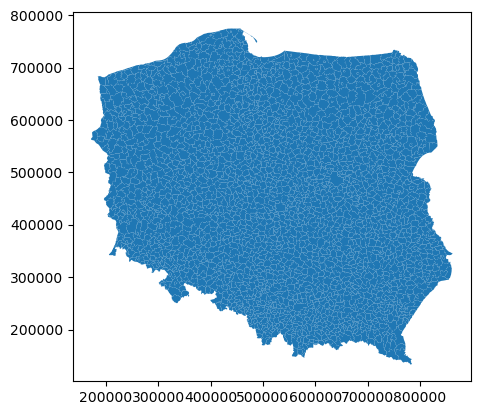

In [11]:
prg_17 = geo_root / "PRG_jednostki_administracyjne_2017"

# Read gminy.shp file with polish characters

gdf = gpd.read_file(prg_17 / "gminy.shp")
gdf = gdf.to_crs(epsg=2180)  # Convert to EPSG:2180
gdf.head()

gdf.plot()


In [12]:
gdf

,iip_przest,iip_identy,iip_wersja,jpt_sjr_ko,jpt_kod_je,jpt_nazwa_,jpt_nazw01,jpt_organ_,jpt_orga01,jpt_jor_id,...,id_bufora_,id_bufor01,id_technic,jpt_opis,jpt_sps_ko,gra_ids,status_obi,opis_bledu,typ_bledu,geometry
0,PL.PZGIK.200,4ed7022d-98d4-4d77-a669-d991d57b76c2,2012-09-26T22:31:18+02:00,GMI,0222033,Wo³ów,None,None,NZN,0.0,...,0.0,13846.0,0.0,827772,UZG,None,AKTUALNY,None,None,"POLYGON ((319872.626 383951.756, 319938.896 38..."
1,PL.PZGIK.200,1187f92d-ba32-4763-9d2d-b3fbb5aa45ae,2012-09-26T22:30:34+02:00,GMI,0214062,Olenica,None,None,NZN,0.0,...,0.0,13838.0,0.0,827704,UZG,None,AKTUALNY,None,None,"POLYGON ((380436.401 368874.817, 380469.12 368..."
2,PL.PZGIK.200,705e301b-c602-4f5e-8a8f-e4a78ef30d9d,2012-09-26T22:31:21+02:00,GMI,0223022,D³ugo³êka,None,None,NZN,0.0,...,0.0,13847.0,0.0,827773,UZG,None,AKTUALNY,None,None,"POLYGON ((365569.582 376008.353, 365574.025 37..."
3,PL.PZGIK.200,3e0bad41-fb26-4775-bc4a-cf03ee4d9bc4,2012-09-26T22:30:34+02:00,GMI,0214073,Syców,None,None,NZN,0.0,...,0.0,13838.0,0.0,827705,UZG,None,AKTUALNY,None,None,"POLYGON ((397867.372 383092.82, 397916.191 383..."
4,PL.PZGIK.200,568bd878-92a7-4b23-b7bf-8c50aa766061,2012-09-26T22:31:21+02:00,GMI,0223012,Czernica,None,None,NZN,0.0,...,0.0,13847.0,0.0,827774,UZG,None,AKTUALNY,None,None,"POLYGON ((370352.948 358781.965, 370409.911 35..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2473,PL.PZGIK.200,e390b182-1829-46d0-9144-e88ca208a0cd,2012-09-26T22:33:42+02:00,GMI,3202023,Choszczno,None,None,NZN,0.0,...,0.0,13603.0,0.0,827986,UZG,None,AKTUALNY,None,None,"POLYGON ((250000.648 601363.188, 250028.644 60..."
2474,PL.PZGIK.200,5a92ba1a-e078-439e-9109-b4634cbbc58d,2012-09-26T22:33:42+02:00,GMI,3202042,Krzêcin,None,None,NZN,0.0,...,0.0,13603.0,0.0,827989,UZG,None,AKTUALNY,None,None,"POLYGON ((258033.681 583822.125, 258069.17 583..."
2475,PL.PZGIK.200,a2a0c06f-7733-4342-8a1d-84f72b53f7bb,2012-09-26T22:33:42+02:00,GMI,3202033,Drawno,None,None,NZN,0.0,...,0.0,13603.0,0.0,827990,UZG,None,AKTUALNY,None,None,"POLYGON ((273360.796 596731.214, 273375.293 59..."
2476,PL.PZGIK.200,6d99fb7a-7ec8-43ac-b737-dc3ab461e94c,2012-09-26T22:33:42+02:00,GMI,3202053,Pe³czyce,None,None,NZN,0.0,...,0.0,13603.0,0.0,827991,UZG,None,AKTUALNY,None,None,"POLYGON ((245705.609 582295.353, 245722.535 58..."


In [90]:
A = {
  "totalRecords": 0,
  "page": 0,
  "pageSize": 0,
  "links": {
    "firstPage": "string",
    "prevPage": "string",
    "self": "string",
    "nextPage": "string",
    "lastPage": "string"
  },
  "results": [
    {
      "metadata": {
        "id": "string",
        "title": "string",
        "url": "string",
        "provider": "string",
        "modificationDate": "2019-08-24T14:15:22Z",
        "description": "string",
        "keywords": "string",
        "temporalCoverage": "string",
        "language": "string",
        "updatePeriod": "string",
        "contentType": "string"
      },
      "version": {
        "id": "string",
        "major": 0,
        "minor": 0,
        "modificationDate": "2019-08-24T14:15:22Z",
        "deprecated": "2019-08-24T14:15:22Z"
      },
      "id": 0,
      "subjectId": "string",
      "n1": "string",
      "n2": "string",
      "n3": "string",
      "n4": "string",
      "n5": "string",
      "level": 0,
      "measureUnitId": 0,
      "measureUnitName": "string"
    }
  ],
  "metadata": {
    "id": "string",
    "title": "string",
    "url": "string",
    "provider": "string",
    "modificationDate": "2019-08-24T14:15:22Z",
    "description": "string",
    "keywords": "string",
    "temporalCoverage": "string",
    "language": "string",
    "updatePeriod": "string",
    "contentType": "string"
  },
  "version": {
    "id": "string",
    "major": 0,
    "minor": 0,
    "modificationDate": "2019-08-24T14:15:22Z",
    "deprecated": "2019-08-24T14:15:22Z"
  }
}

In [108]:
A.get("results")[0].get("metadata")